In [12]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
#filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
filtered_time = pd.read_csv("filtered_time_normalized.csv", index_col=0)
data_orig = data_orig.loc[filtered_time.index]
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0       True
1       True
2       True
3       True
4       True
        ... 
5144    True
5145    True
5146    True
5147    True
5148    True
Name: time_to_next_ev_hr, Length: 5149, dtype: bool
(5145, 3)
Next slips shape (5145, 8)
orig shape (5149, 8)


In [14]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-16 22:16:11,036] A new study created in memory with name: no-name-c265533d-09d0-4610-b8a1-e2a36756e7ad
[I 2026-02-16 22:16:11,514] Trial 0 finished with value: 8013.516934644432 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 8013.516934644432.
[I 2026-02-16 22:16:11,817] Trial 1 finished with value: 7715.4373143149105 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 1 with value: 7715.4373143149105.
[I 2026-02-16 22:16:12,192] Trial 2 finished with value: 10632.920195243545 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 1 with value: 7715.4373143149105.
[I 2026-02-16 22:16:12,553] Trial 3 finished with value: 8516.13607542003 and p

Optimal Parameters: {'learning_rate': 0.053691166620747334, 'max_depth': 5, 'subsample': 0.6734720831659005, 'colsample_bytree': 0.8275489439447102}
XGBoost Error: 48832.677317452115
Mean XGBoost Error: 3285.078566975837


4230    4823.561494
3715    2960.439863
4415    4256.953216
4253    2497.211429
459     2571.077062
           ...     
4480    4616.479250
3136    3236.800478
1877    3411.452801
1171    2789.501653
2461    2737.905832
Name: time_to_next_ev_hr, Length: 1029, dtype: float64
[4145.861  2868.77   5262.6113 ... 3343.0862 3547.9182 4938.558 ]
Sample0: True = 4823.561494266571s, Predicted = 4145.86083984375s, Error=677.7006544228207s
Sample1: True = 2960.4398628539975s, Predicted = 2868.77001953125s, Error=91.66984332274751s
Sample2: True = 4256.953216008464s, Predicted = 5262.611328125s, Error=1005.6581121165364s
Sample3: True = 2497.2114292831056s, Predicted = 3248.2626953125s, Error=751.0512660293944s
Sample4: True = 2571.07706221148s, Predicted = 4889.767578125s, Error=2318.69051591352s
Sample5: True = 5453.9077864039455s, Predicted = 2950.545166015625s, Error=2503.3626203883205s
Sample6: True = 2978.746239373447s, Predicted = 2313.653076171875s, Error=665.0931632015722s
Sample7: True =

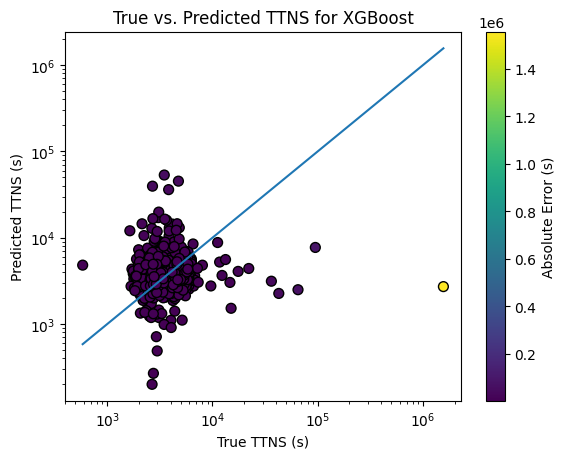

In [20]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

In [16]:
# Compute absolute errors
print("Length of Subset", len(XG_pred_secs))
diff = np.abs(XG_pred_secs - y_test_secs)

# Threshold for outliers
threshold = 20000  # adjust as needed

# Get indices of outliers in the test set
X_outliers = np.where(diff > threshold)[0]

print("Number of Outliers", len(X_outliers))
print(f"Outliers (error > {threshold}):")

# Print details for only outliers
for idx in X_outliers:
    true = y_test_secs.iloc[idx]   # pandas Series: use iloc
    pred = XG_pred_secs[idx]       # numpy array: use normal indexing
    print(f"Index position {idx}: True={true}, Predicted={pred}")

Length of Subset 1029
Number of Outliers 9
Outliers (error > 20000):
Index position 280: True=3837.9214691768143, Predicted=36073.7890625
Index position 345: True=4753.307246943093, Predicted=45231.6796875
Index position 396: True=64958.21545244713, Predicted=2501.9189453125
Index position 481: True=42676.13696774051, Predicted=2265.6962890625
Index position 488: True=2696.6824089285187, Predicted=39562.84375
Index position 563: True=94877.62347529877, Predicted=7721.173828125
Index position 834: True=1560700.5931698263, Predicted=2718.107666015625
Index position 938: True=3488.2726320552842, Predicted=53242.8828125
Index position 959: True=36285.60999698572, Predicted=3138.7666015625


 97%|=================== | 996/1029 [00:22<00:00]       

XG Boost Drivers: tide_height    1581.765782
slip_size      1182.215562
time_since     1079.023006
tide_deriv      633.023112
form_fac        620.714996
high_t_evt      323.576618
dtype: float64


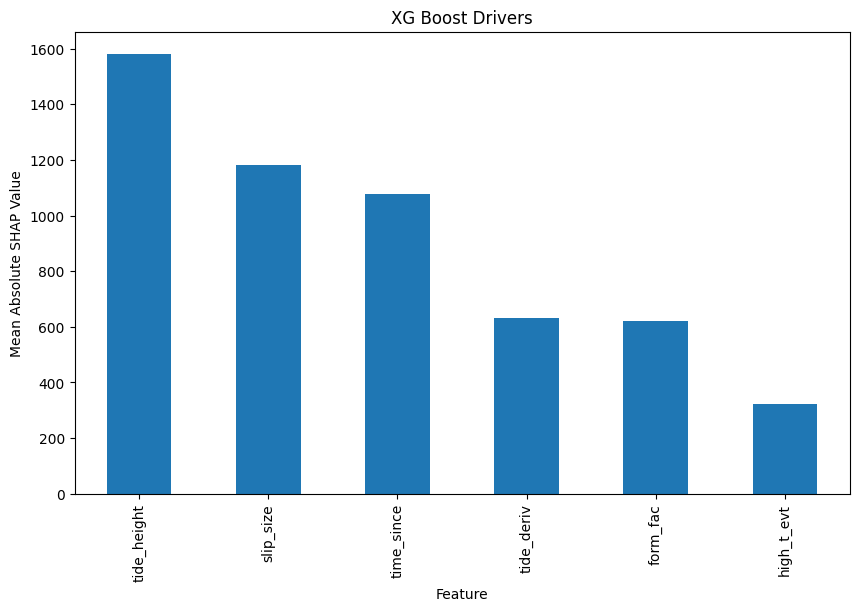

In [17]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
